<a href="https://colab.research.google.com/github/rafiatoumalamali-cell/LabProjectRafiatouMalamAli/blob/main/02_baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#2.0 Setup & Loading Cleaned Data

---

In [ ]:
# Import neccesary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cleaned data from github, "Intro-to-AI-Project/data/processed"
github_url = "https://raw.githubusercontent.com/fredd-a/Intro-to-AI-Project/main/data/processed/student_performance_cleaned.csv"

df = pd.read_csv(github_url)

# Verify that the cleaned dataset loaded successfully
print("Dataset shape:", df.shape)

# View first rows
df.head(10)

Dataset shape: (960, 9)


,StudentID,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Online Classes Taken
0,1,Male,85.0,15.0,78.0,1.0,High,80.0,False
1,2,Female,90.0,20.0,85.0,2.0,Medium,87.0,True
2,3,Male,78.0,10.0,65.0,0.0,Low,68.0,False
3,4,Male,92.0,25.0,90.0,3.0,High,92.0,False
4,5,Female,88.0,18.0,82.0,2.0,Medium,85.0,True
5,6,Female,95.0,30.0,88.0,1.0,High,80.0,False
6,7,Male,70.0,8.0,60.0,0.0,Low,62.0,False
7,8,Female,88.0,17.0,77.0,1.0,Medium,78.0,True
8,9,Male,82.0,12.0,70.0,2.0,Low,72.0,False
9,10,Female,91.0,22.0,86.0,3.0,High,88.0,True


#2.1 Defining Risk Categories

---



In [ ]:
df["FinalGrade"].describe()

,FinalGrade
count,960.00000
mean,80.12500
std,9.32313
min,62.00000
25%,72.00000
50%,80.00000
75%,88.00000
max,92.00000


In [ ]:
# Implement the classification targets from final grade (low,medium,high risk)
def classify_risk(grade):
    if grade < 75:
        return "High Risk"
    elif grade < 85:
        return "Medium Risk"
    else:
        return "Low Risk"


df["RiskCategory"] = df["FinalGrade"].apply(classify_risk)


df[["FinalGrade", "RiskCategory"]].head()

,FinalGrade,RiskCategory
0,80.0,Medium Risk
1,87.0,Low Risk
2,68.0,High Risk
3,92.0,Low Risk
4,85.0,Low Risk


In [ ]:
# Examine the distribution of the target classes before training
df["RiskCategory"].value_counts()


,count
RiskCategory,
Low Risk,448
High Risk,275
Medium Risk,237


In [ ]:
df["RiskCategory"].value_counts(normalize=True)*100

,proportion
RiskCategory,
Low Risk,46.666667
High Risk,28.645833
Medium Risk,24.687500


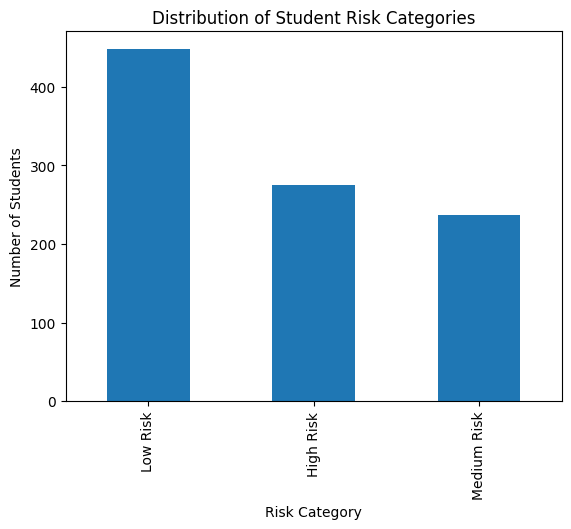

In [ ]:
df["RiskCategory"].value_counts().plot(
    kind="bar",
    xlabel="Risk Category",
    ylabel="Number of Students",
    title="Distribution of Student Risk Categories"
)

plt.show()

The target variable was created from FinalGrade by grouping students into three academic risk categories. Students with grades below 75 were classified as High Risk, grades between 75 and 84 as Medium Risk, and grades of 85 or above as Low Risk. These thresholds were selected based on the dataset distribution, where the minimum grade was 62 and the median grade was 80. This ensures that all three categories contain sufficient examples for classification.

#2.2 Feature Selection:

---



# Inspect the dataset before feature selection and encoding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    int64  
 1   Gender                     960 non-null    object 
 2   AttendanceRate             960 non-null    float64
 3   StudyHoursPerWeek          960 non-null    float64
 4   PreviousGrade              960 non-null    float64
 5   ExtracurricularActivities  960 non-null    float64
 6   ParentalSupport            960 non-null    object 
 7   FinalGrade                 960 non-null    float64
 8   Online Classes Taken       960 non-null    bool   
 9   RiskCategory               960 non-null    object 
dtypes: bool(1), float64(5), int64(1), object(3)
memory usage: 68.6+ KB


# Separate predictor variables (X) from the target variable (y))

In [ ]:
# Encode categoricals (everthing except 'FinalGrade', 'StudentID'): binary map (Gender, Online Classes Taken), ordinal map (ParentalSupport: Low/Medium/High).
# Reasoning cell explaining each encoding choice.

# Separate input features and prediction target

X = df.drop(columns=["StudentID", "FinalGrade", "RiskCategory"])

y = df["RiskCategory"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,Online Classes Taken
0,Male,85.0,15.0,78.0,1.0,High,False
1,Female,90.0,20.0,85.0,2.0,Medium,True
2,Male,78.0,10.0,65.0,0.0,Low,False
3,Male,92.0,25.0,90.0,3.0,High,False
4,Female,88.0,18.0,82.0,2.0,Medium,True



Target:


,RiskCategory
0,Medium Risk
1,Low Risk
2,High Risk
3,Low Risk
4,Low Risk


### Encode Gender

Gender has no natural ordering (Male/Female), so binary encoding is appropriate.

In [ ]:
gender_map = {
    "Male": 1,
    "Female": 0
}

X["Gender"] = X["Gender"].map(gender_map)

Encode Online Classes Taken to number true = 1, false = 0.           Because Random Forest can handle numbers better

In [ ]:
X["Online Classes Taken"] = X["Online Classes Taken"].astype(int)

Encode ParentalSupport, this is an ordinal variable because there is an order. Low < Medium < High  

Therefore,
                                                                
Low = 0
Medium = 1
High = 2

In [ ]:
support_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

X["ParentalSupport"] = X["ParentalSupport"].map(support_map)

# Verify that all categorical features have been encoded correctly

In [ ]:
X.head()

,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,Online Classes Taken
0,1,85.0,15.0,78.0,1.0,2,0
1,0,90.0,20.0,85.0,2.0,1,1
2,1,78.0,10.0,65.0,0.0,0,0
3,1,92.0,25.0,90.0,3.0,2,0
4,0,88.0,18.0,82.0,2.0,1,1


Encoding Decisions

Categorical variables were converted into numerical representations because machine learning algorithms require numerical inputs.



Gender: Binary encoding was used because Gender contains two categories without any natural ordering (Male/Female).
Online Classes Taken: Binary encoding was applied because it represents a yes/no condition.
ParentalSupport: Ordinal encoding was used because the categories have a meaningful ranking: Low, Medium, and High. Assigning numerical values preserves this relationship.



At this stage, the dataset has been cleaned, the target variable has been defined, categorical variables have been encoded, and the feature matrix is ready for model training. The next step is to split the data into training and testing sets.

#2.3 Train/Test Split

---



In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Gender                     960 non-null    int64  
 1   AttendanceRate             960 non-null    float64
 2   StudyHoursPerWeek          960 non-null    float64
 3   PreviousGrade              960 non-null    float64
 4   ExtracurricularActivities  960 non-null    float64
 5   ParentalSupport            960 non-null    int64  
 6   Online Classes Taken       960 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 52.6 KB


All categorical variables have been converted into numerical values, and only predictive features remain in the feature matrix (X). The target variable (RiskCategory) has been separated into y. The dataset is now ready to be divided into training and testing sets for model development.

In [ ]:
# Stratified split (since it's classification) on the risk-category target.
# Print resulting sizes and confirm class balance is preserved in both sets.

#2.4 Baseline Comparator

---



In [ ]:
# A dumb baseline (e.g. always predict the majority class)
# Establishes the floor Random Forest needs to beat.
# Report its accuracy.

#2.5 Random Forest Classifier (Main Model)

---



In [ ]:
# Fit RandomForestClassifier with random_state set
# Modest constraints (max_depth, min_samples_leaf) given the dataset size
# Print basic fit confirmation

#2.6 Evaluating the Classifier

---



In [ ]:
# Accuracy, precision/recall/F1 (per class)
# Confusion Matrix
# Comment on why precision/recall matters more than raw accuracy (the cost of missing an at risk student)

#2.7 Feature Importance (Classifier)

---



In [ ]:
# Plot importances
# Reasoning cell interpreting results — flag PreviousGrade dominance if it appears

# Note where Online Classes Taken lands relative to your EDA finding.
# (Explanation) During the data cleaning I found that for 'OnlineClassesTaken' there was no difference in
# final grade between those marked true and those marked false, how does what I found compare with what you find here.

#2.8 Random Forest Regressor (Secondary Model)

---



In [ ]:
# Same features, same split logic, but predicting raw FinalGrade.

# The main model (2.5) gives results in terms of classification, (e.g high risk, medium risk)
# This model is supplementary to that and gives us the prediction of the final grade
# Brief reasoning cell framing this as supplementary detail alongside the classification result, not the headline.

#2.9 Evaluating the Regressor

---



In [ ]:
# RMSE, MAE, R². Optional: predicted vs. actual scatter plot.

#2.10 Summary & Next Steps
---

In [ ]:
# Markdown cell tying it together: baseline vs Random Forest comparison, key findings
# What's due for Week 12